## Week one: Disease Outbreak Analysis
Name - Tshering Gyurmed Bhutia

Domain - Medical Science

Task - Find null values, find duplicate values, remove them, and show every output clearly.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("Outbreaks.csv")

print("Original Dataset")
print(df.head(5))

Original Dataset
     ID        Date   Country  Disease Update  Month  Year  Cases  Deaths
0  2483  23/04/2009     Egypt    Avian    Yes      4  2009     67      23
1  2433  28/05/2009     Egypt    Avian    Yes      5  2009     76      27
2  2485  17/04/2009     Egypt    Avian    Yes      4  2009     64      23
3  2509  30/01/2009  Zimbabwe  Cholera     No      1  2009      0       0
4  2376  11/12/2009  Viet Nam    Avian    Yes     12  2009    112      57


In [71]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nNull Values:")
print(df.isnull().sum())


Dataset Shape:
(13280, 9)

Column Names:
['ID', 'Date', 'Country', 'Disease', 'Update', 'Month', 'Year', 'Cases', 'Deaths']

Null Values:
ID          0
Date        0
Country     0
Disease    90
Update      0
Month       0
Year        0
Cases       0
Deaths      0
dtype: int64


In [72]:
null_info = df[df.isnull().any(axis=1)].copy()

null_info["Null_Count"] = null_info.isnull().sum(axis=1)

print("\nRows Containing Null Values:")
print(null_info)


Rows Containing Null Values:
        ID        Date    Country Disease Update  Month  Year  Cases  Deaths  \
81      15  05/01/2020      China     NaN     No      1  2020     44       0   
105    979  06/05/1997    Burundi     NaN     No      5  1997  24000       0   
106    992  12/03/1997     Uganda     NaN     No      3  1997      2       0   
110   1009  20/01/1997     Rwanda     NaN     No      1  1997     56       2   
183     65  06/07/2012   Cambodia     NaN    Yes      7  2012     74      56   
...    ...         ...        ...     ...    ...    ...   ...    ...     ...   
2208   801  25/06/2003      China     NaN    Yes      6  2003      0       0   
2214   804  23/06/2003  Hong Kong     NaN    Yes      6  2003      0       0   
2223   834  23/05/2003  Hong Kong     NaN    Yes      5  2003      5       0   
2231   819  09/06/2003      China     NaN    Yes      6  2003      5       1   
2232   799  27/06/2003      Japan     NaN    Yes      6  2003      0       0   

      Nul

In [ ]:
#ID	Disease	Deaths
#1	NaN	     20
#2	COVID	 10

#ID	Disease	Deaths
#False	True	False
#False	False	False

#Row	Contains Null?
#Row 1	True
#Row 2	False

#ID	Disease	Deaths
#1	NaN	    20
-------------------
#ID	Disease	Deaths
#False	True	False
#0    +    1  +   0 =   1

#1 null value




In [73]:
df_clean = df.dropna()

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nCleaned Dataset Shape:")
print(df_clean.shape)

print("\nCleaned Dataset Preview:")
print(df_clean.head())


Original Dataset Shape:
(13280, 9)

Cleaned Dataset Shape:
(13190, 9)

Cleaned Dataset Preview:
     ID        Date   Country  Disease Update  Month  Year  Cases  Deaths
0  2483  23/04/2009     Egypt    Avian    Yes      4  2009     67      23
1  2433  28/05/2009     Egypt    Avian    Yes      5  2009     76      27
2  2485  17/04/2009     Egypt    Avian    Yes      4  2009     64      23
3  2509  30/01/2009  Zimbabwe  Cholera     No      1  2009      0       0
4  2376  11/12/2009  Viet Nam    Avian    Yes     12  2009    112      57


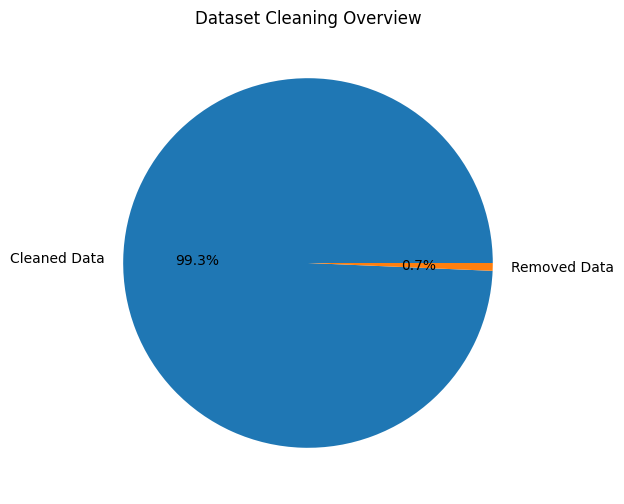

In [74]:
labels = ['Cleaned Data', 'Removed Data']

values = [
    df_clean.shape[0],
    df.shape[0] - df_clean.shape[0]
]

plt.figure(figsize=(6,6))

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Dataset Cleaning Overview")

plt.show()


## finding duplicate values in important columns

In [80]:
duplicate_ids = df[df.duplicated(subset=['ID'])]

print(duplicate_ids)

Empty DataFrame
Columns: [ID, Date, Country, Disease, Update, Month, Year, Cases, Deaths]
Index: []


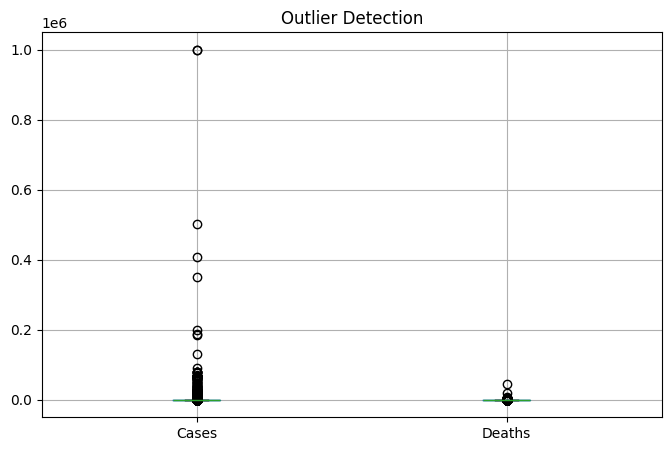

In [76]:
plt.figure(figsize=(8,5))

df.boxplot(column=['Cases', 'Deaths'])

plt.title("Outlier Detection")

plt.show()

In [77]:
from sklearn.preprocessing import LabelEncoder

country_encoder = LabelEncoder()
disease_encoder = LabelEncoder()
update_encoder = LabelEncoder()

df['Country'] = country_encoder.fit_transform(df['Country'])

df['Disease'] = disease_encoder.fit_transform(df['Disease'])

df['Update'] = update_encoder.fit_transform(df['Update'])

print("\nEncoded Dataset:")
print(df.head())



Encoded Dataset:
     ID        Date  Country  Disease  Update  Month  Year  Cases  Deaths
0  2483  23/04/2009       60        5       1      4  2009     67      23
1  2433  28/05/2009       60        5       1      5  2009     76      27
2  2485  17/04/2009       60        5       1      4  2009     64      23
3  2509  30/01/2009      226       10       0      1  2009      0       0
4  2376  11/12/2009      222        5       1     12  2009    112      57


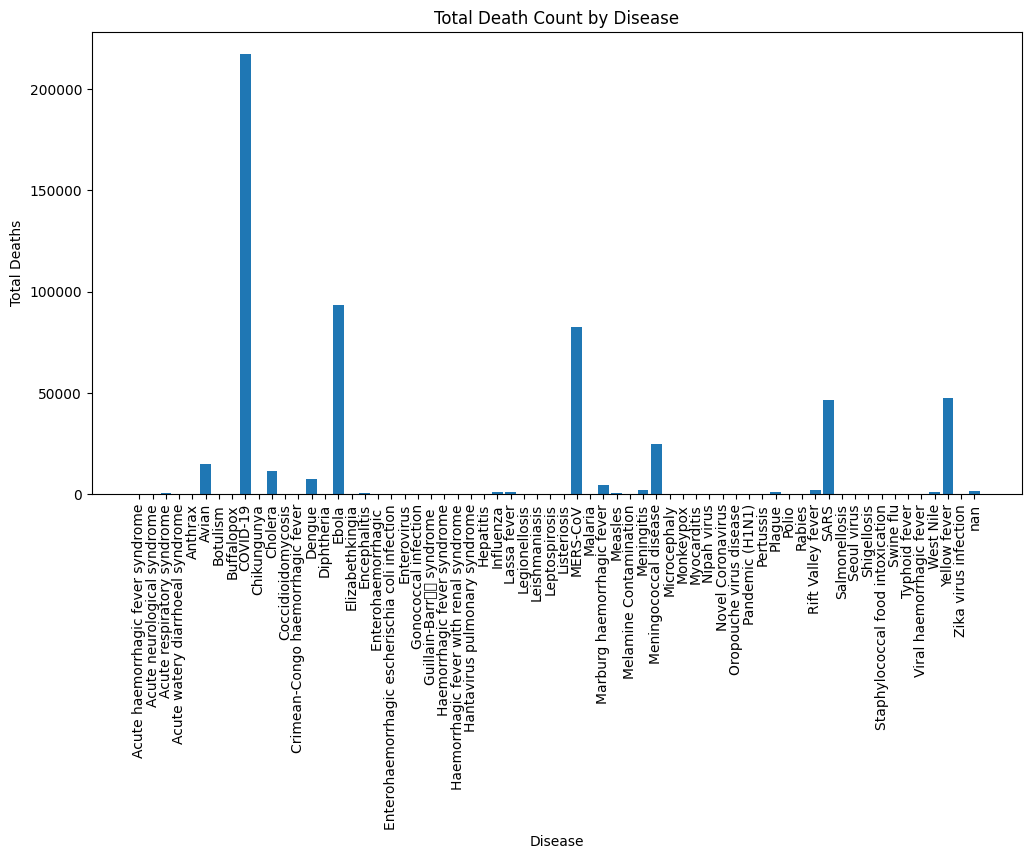


Disease Encoding Classes:
['Acute haemorrhagic fever syndrome' 'Acute neurological syndrome'
 'Acute respiratory syndrome' 'Acute watery diarrhoeal syndrome' 'Anthrax'
 'Avian' 'Botulism' 'Buffalopox' 'COVID-19' 'Chikungunya' 'Cholera'
 'Coccidioidomycosis' 'Crimean-Congo haemorrhagic fever' 'Dengue'
 'Diphtheria' 'Ebola' 'Elizabethkingia' 'Encephalitis'
 'Enterohaemorrhagic ' 'Enterohaemorrhagic escherischia coli infection'
 'Enterovirus' 'Gonococcal infection' 'Guillain-Barr脙漏 syndrome '
 'Haemorrhagic fever syndrome' 'Haemorrhagic fever with renal syndrome'
 'Hantavirus pulmonary syndrome' 'Hepatitis' 'Influenza' 'Lassa fever'
 'Legionellosis' 'Leishmaniasis' 'Leptospirosis' 'Listeriosis' 'MERS-CoV'
 'Malaria' 'Marburg haemorrhagic fever' 'Measles' 'Melamine Contamination'
 'Meningitis' 'Meningococcal disease' 'Microcephaly' 'Monkeypox'
 'Myocarditis' 'Nipah virus' 'Novel Coronavirus' 'Oropouche virus disease'
 'Pandemic (H1N1)' 'Pertussis' 'Plague' 'Polio' 'Rabies'
 'Rift Valley f

In [82]:
disease_deaths = df.groupby('Disease')['Deaths'].sum()

disease_names = disease_encoder.classes_


x_labels = [str(disease_names[int(i)]) for i in disease_deaths.index]


plt.figure(figsize=(12,6))

plt.bar(x_labels, disease_deaths.values)

plt.xticks(rotation=90)

plt.title("Total Death Count by Disease")

plt.xlabel("Disease")

plt.ylabel("Total Deaths")

plt.show()

print("\nDisease Encoding Classes:")
print(disease_encoder.classes_)

print("\nDisease represented by encoded value 8:")
print(disease_encoder.classes_[8])

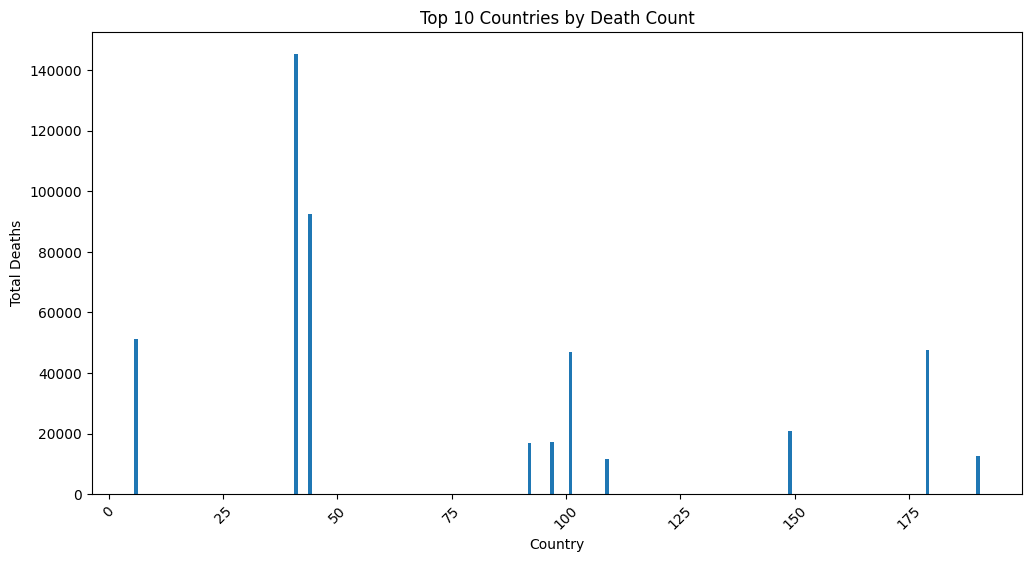

In [79]:
country_deaths = df.groupby('Country')['Deaths'].sum()

top_10 = country_deaths.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_10.index, top_10.values)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Death Count")

plt.xlabel("Country")

plt.ylabel("Total Deaths")

plt.show()

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_normalize = [
    'Month',
    'Year',
    'Cases',
    'Deaths'
]

df[columns_to_normalize] = scaler.fit_transform(
    df[columns_to_normalize]
)
print("\nNormalized Dataset:")
print(df.head())


Normalized Dataset:
     ID        Date  Country  Disease  Update     Month      Year     Cases  \
0  2483  23/04/2009       60        5       1  0.272727  0.541667  0.000067   
1  2433  28/05/2009       60        5       1  0.363636  0.541667  0.000076   
2  2485  17/04/2009       60        5       1  0.272727  0.541667  0.000064   
3  2509  30/01/2009      226       10       0  0.000000  0.541667  0.000000   
4  2376  11/12/2009      222        5       1  1.000000  0.541667  0.000112   

     Deaths  
0  0.000523  
1  0.000614  
2  0.000523  
3  0.000000  
4  0.001295  


In [60]:
print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Processed Dataset:")
print(df.head())


Final Dataset Shape:
(13280, 9)

Final Processed Dataset:
     ID        Date  Country  Disease  Update     Month      Year     Cases  \
0  2483  23/04/2009       60        5       1  0.272727  0.541667  0.000067   
1  2433  28/05/2009       60        5       1  0.363636  0.541667  0.000076   
2  2485  17/04/2009       60        5       1  0.272727  0.541667  0.000064   
3  2509  30/01/2009      226       10       0  0.000000  0.541667  0.000000   
4  2376  11/12/2009      222        5       1  1.000000  0.541667  0.000112   

     Deaths  
0  0.000523  
1  0.000614  
2  0.000523  
3  0.000000  
4  0.001295  
